(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

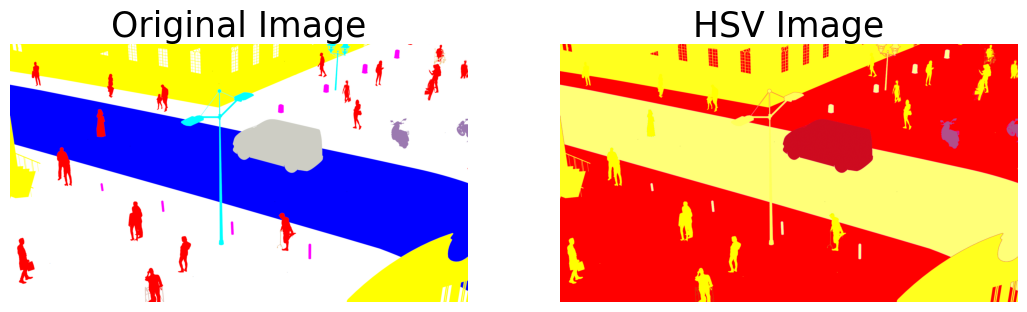

In [2]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number
import matplotlib.pyplot as plt
import cv2 as cv
import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

# Choose image for treatment
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

"""
Studying Color Conversion in OpenCV:
    https://docs.opencv.org/4.10.0/d8/d01/group__imgproc__color__conversions.html
    https://docs.opencv.org/4.10.0/de/d25/imgproc_color_conversions.html#color_convert_rgb_hsv
"""

# Load image in RGB Color Model (Red, Green, Blue).
# Note: BGR format is the OpenCV Standard, 1 is for RGB (True Color) and 0 for Grayscale
bgr_img = cv.imread(mask_path, 1)

# Convert to HSV Color Model (Hue, Saturation, Value of Intensity)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Plotting the Images using he RGB Color Model and HSV Color Model
plt.figure(figsize=[13,13])
plt.subplot(121);plt.imshow(bgr_img[:,:,::-1]);plt.title("Original Image",fontdict={'fontsize': 25});plt.axis('off')
plt.subplot(122);plt.imshow(hsv_img[:,:,::-1]);plt.title("HSV Image",fontdict={'fontsize': 25});plt.axis('off')

In [3]:
# Alternative to Inspect the Color Values for each Pixel
cv.imshow("HSV Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

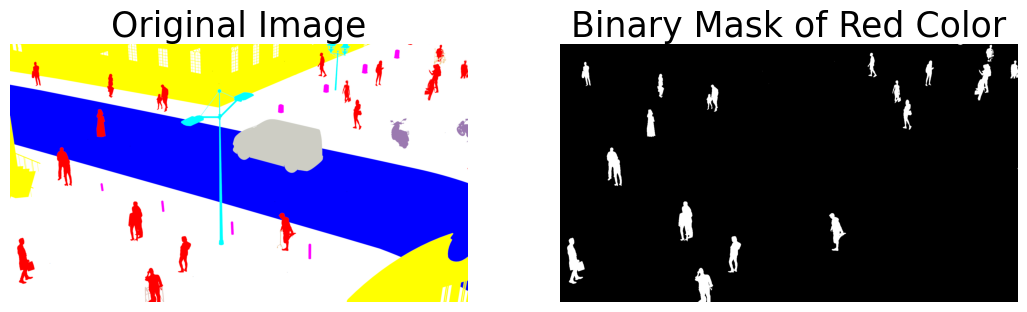

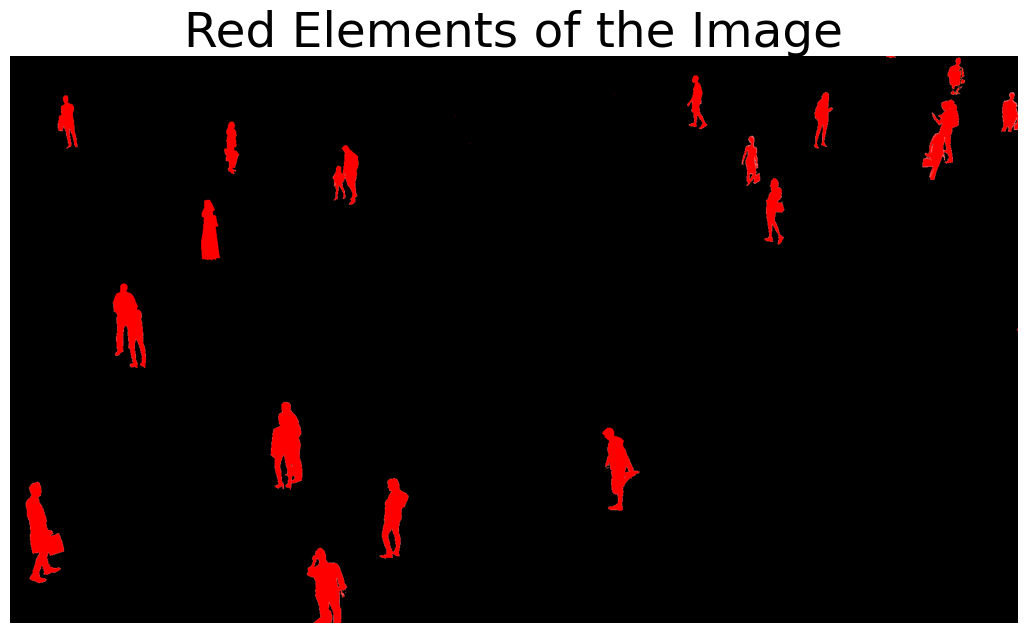

In [12]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import os

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para RED ###

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Define limits for Red Color (Ainda tenho dúvidas neste processo)
lower_red = np.array([0, 100, 100])  # Minimum Values for H, S, V   >> H = 0 para Vermelho puro
upper_red = np.array([10, 255, 255])  # Maximum Values for H, S, V  >> H = 10 para Vermelho próximo da cor Magenta

# Create binary mask
mask = cv.inRange(hsv_img, lower_red, upper_red)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title("Original Image",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Red Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Red Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

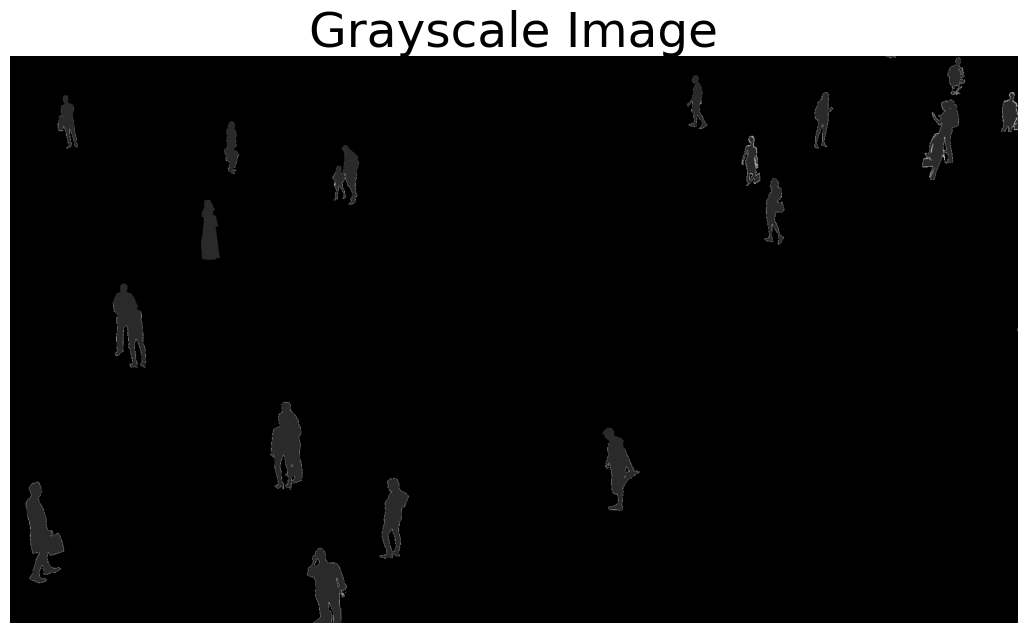

In [9]:
# Convert Result to Grayscale
gray_img = cv.cvtColor(result, cv.COLOR_RGB2GRAY)

plt.figure(figsize=[13,13])
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image",fontdict={'fontsize':35})
plt.axis('off')

# cv.imshow("Grayscale Image", gray_img)
# cv.waitKey(0)
# cv.destroyAllWindows()